In [284]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [285]:
df = pd.read_csv('adult.csv')

In [286]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 48842
Columns: 15


In [287]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [288]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [289]:
skew_cpy = df.select_dtypes(include='number').copy()
skew_cpy.skew()

,0
age,0.557580
fnlwgt,1.438892
educational-num,-0.316525
capital-gain,11.894659
capital-loss,4.569809
hours-per-week,0.238750


In [290]:
# Remove duplicate rows

dup = df.duplicated()
df_dup = df[dup]

df.drop(df_dup.index, axis=0, inplace=True)

In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        48790 non-null  object
 2   fnlwgt           48790 non-null  int64 
 3   education        48790 non-null  object
 4   educational-num  48790 non-null  int64 
 5   marital-status   48790 non-null  object
 6   occupation       48790 non-null  object
 7   relationship     48790 non-null  object
 8   race             48790 non-null  object
 9   gender           48790 non-null  object
 10  capital-gain     48790 non-null  int64 
 11  capital-loss     48790 non-null  int64 
 12  hours-per-week   48790 non-null  int64 
 13  native-country   48790 non-null  object
 14  income           48790 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [292]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Section II: EDA & Further Preprocessing

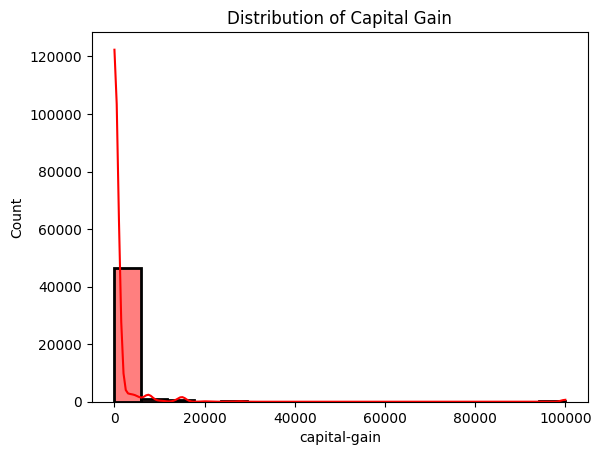

In [293]:
# Plot distribution of capital gain (skew is 11)

plt.title('Distribution of Capital Gain')
sns.histplot(data=df, x='capital-gain', color='red', edgecolor='black', linewidth=2, kde=True)
plt.show()

**NOTE: Extremely right skewed**

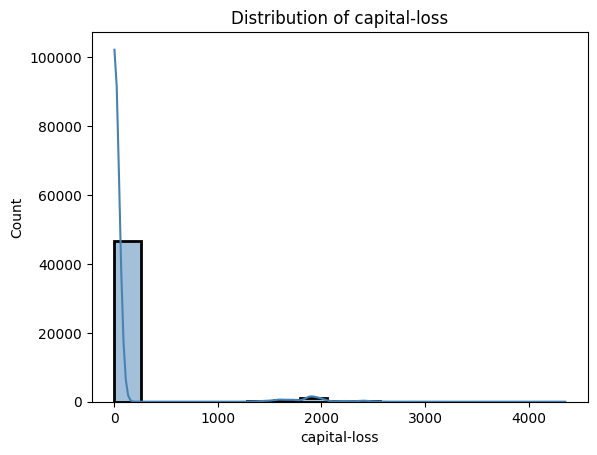

In [294]:
# Plot distriubtion of capital loss (skew is 4)

plt.title('Distribution of capital-loss')
sns.histplot(data=df, x='capital-loss', color='steelblue', edgecolor='black', linewidth=2, kde=True)
plt.show()

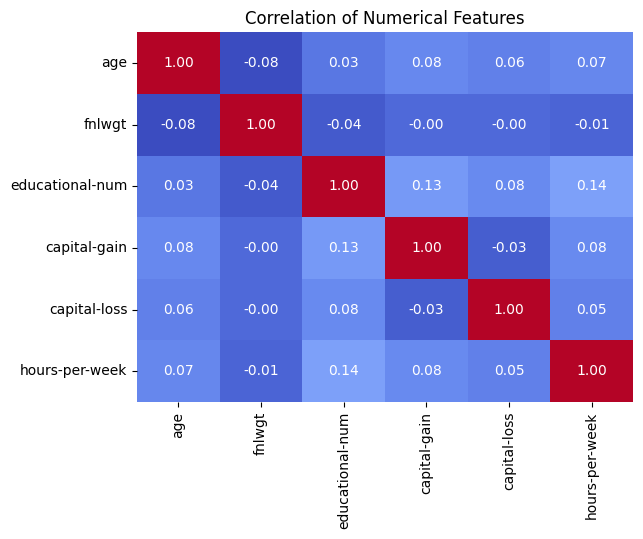

In [295]:
# Plot correlation matrix

df_num_cpy = df.select_dtypes(include='number').copy()
sns.heatmap(data=df_num_cpy.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Correlation of Numerical Features')
plt.show()

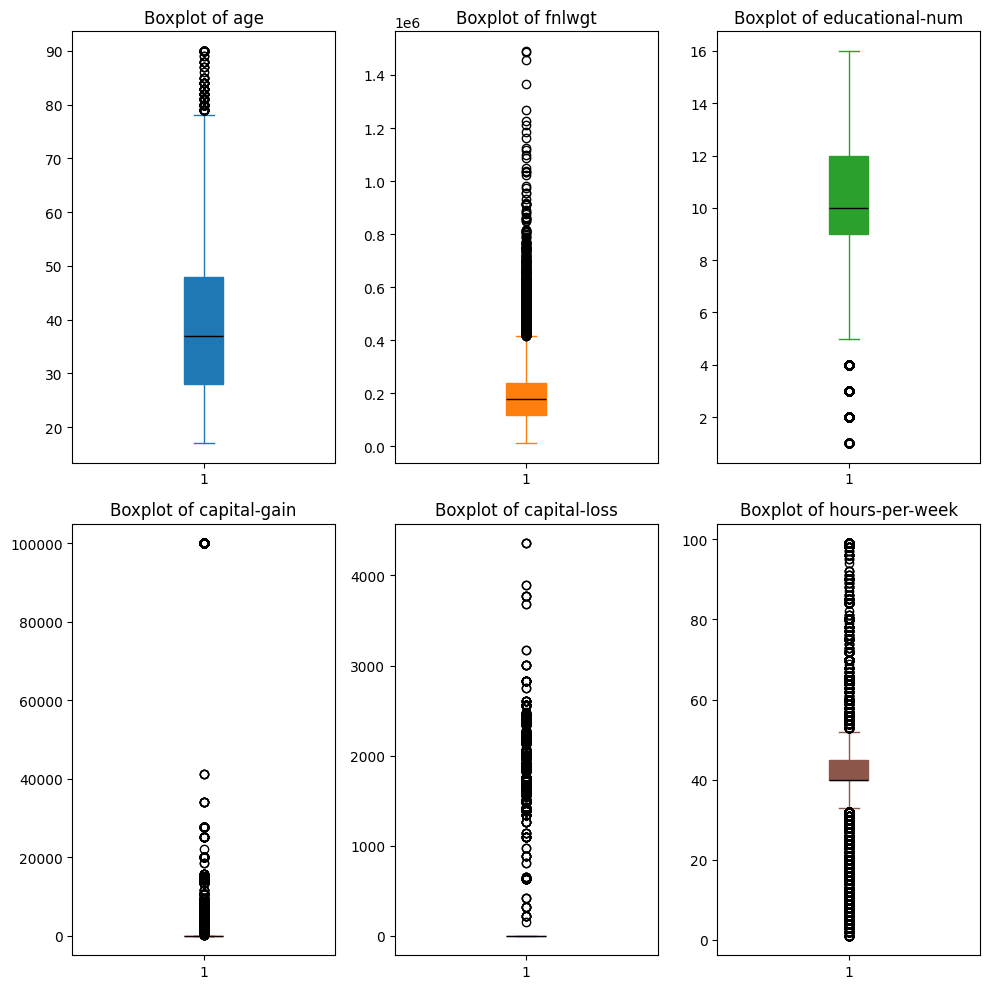

In [296]:
# See outliers for all columns

import matplotlib.colors as mcolors

fig, ax = plt.subplots(2, 3, figsize=(10, 10))

colors = list(mcolors.TABLEAU_COLORS.values())

for idx, col in enumerate(df_num_cpy.columns):
  r = idx // 3
  c = idx % 3

  color = colors[idx]

  ax[r][c].boxplot(
      df[col].values,
      patch_artist=True,
      boxprops=dict(facecolor=color, edgecolor=color),
      whiskerprops=dict(color=color),
      capprops=dict(color=color),
      medianprops=dict(color="black")
  )
  ax[r][c].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [297]:
df['education'].value_counts().index

Index(['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Assoc-voc', '11th',
       'Assoc-acdm', '10th', '7th-8th', 'Prof-school', '9th', '12th',
       'Doctorate', '5th-6th', '1st-4th', 'Preschool'],
      dtype='object', name='education')

In [298]:
# Drop NaN (i.e. '?') values

df = df[(df['occupation'] != '?') & (df['native-country'] != '?') & (df['workclass'] != '?')]

In [299]:
# Encode the dataset

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

education_order = [[
    'Preschool',
    '1st-4th',
    '5th-6th',
    '7th-8th',
    '9th',
    '10th',
    '11th',
    '12th',
    'HS-grad',
    'Some-college',
    'Assoc-voc',
    'Assoc-acdm',
    'Bachelors',
    'Masters',
    'Prof-school',
    'Doctorate'
]]

# Encode income column
df['income'] = np.where(df['income'] == ">=50K", 1, 0)

nominal_cols = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
]

oe = OrdinalEncoder(categories=education_order)
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

income_col = df['income']
df.drop('income', axis=1, inplace=True)

# Encode education column
df[['education']] = oe.fit_transform(df[['education']])

# One-hot encode nominal columns
ohe_encoded = ohe.fit_transform(df[nominal_cols])

df.drop(columns=nominal_cols, inplace=True)

df = pd.concat([df, ohe_encoded], axis=1)
df = pd.concat([df, income_col], axis=1)

df.head()


,age,fnlwgt,education,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,25,226802,6.0,7,0,0,40,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,38,89814,8.0,9,0,0,50,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,28,336951,11.0,12,0,0,40,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,44,160323,9.0,10,7688,0,40,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
5,34,198693,5.0,6,0,0,30,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [300]:
# Save dataset as pickle

df.to_pickle('adult-income.pkl')